In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.io_utils import (load_pickle_file,
    get_project_path,
    load_csv_file
)

from flonacomldft.models.mlp import MLP
from flonacomldft.train_mlp_from_data import train_mlp

import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression

In [3]:
path_from_adaptive = "/1-adaptive"
adaptive_to_load = lambda isomer, idx: "results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(
        isomer, 
        idx, 
        isomer, 
        idx)

# MCMC

In [4]:
mcmcs = {i: torch.cat(load_pickle_file(adaptive_to_load(i, idx),
        get_project_path() + path_from_adaptive)['xs']) for i, idx in enumerate([31961552, 31961553])}

Text(0.5, 0.98, 'Correlation matrix of the MCMC samples')

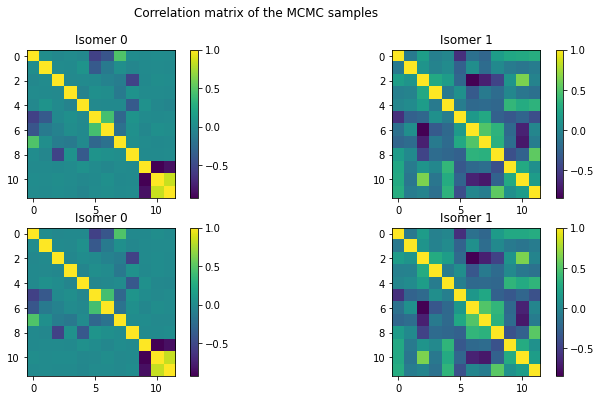

In [5]:
skip = 10
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

for i, ax in enumerate(axs[0]):
    im = ax.imshow(torch.corrcoef(mcmcs[i][::skip].reshape(-1, 12).transpose(0, 1)))
    # add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)

    ax.set_title('Isomer {:d}'.format(i))

for i, ax in enumerate(axs[1]):
    im = ax.imshow(torch.corrcoef(mcmcs[i].reshape(-1, 12).transpose(0, 1)))
    # add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)

    ax.set_title('Isomer {:d}'.format(i))

fig.suptitle('Correlation matrix of the MCMC samples')

Text(0.5, 0.98, 'Mutual information for MCMC')

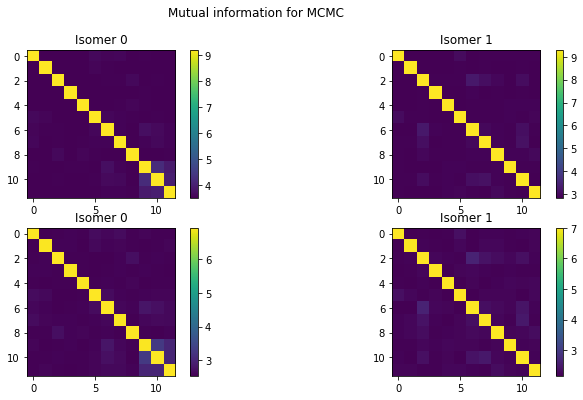

In [6]:
skip = 10
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

for i, ax in enumerate(axs[0]):
    mutual_info_matrix = []
    for j in range(12):
    #print(mutual_info_regression(mcmcs[0][::skip, 0].detach().numpy(), mcmcs[0][::skip, 0].detach().numpy()[:, i]))
        mutual_info_matrix.append(
            mutual_info_regression(mcmcs[i].reshape(-1, 12).detach().numpy(), mcmcs[i].reshape(-1, 12).detach().numpy()[:, j])
        )

    im = ax.imshow(mutual_info_matrix)
    # add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)

    ax.set_title("Isomer {:d}".format(i))

for i, ax in enumerate(axs[1]):
    mutual_info_matrix = []
    for j in range(12):
    #print(mutual_info_regression(mcmcs[0][::skip, 0].detach().numpy(), mcmcs[0][::skip, 0].detach().numpy()[:, i]))
        mutual_info_matrix.append(
            mutual_info_regression(mcmcs[i].reshape(-1, 12)[::skip].detach().numpy(), mcmcs[i].reshape(-1, 12)[::skip].detach().numpy()[:, j])
        )

    im = ax.imshow(mutual_info_matrix)
    # add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)

    ax.set_title("Isomer {:d}".format(i))

fig.suptitle("Mutual information for MCMC")

# MD correlation

In [7]:
md = {i: load_csv_file("is{:d}_flow_train.csv".format(i), get_project_path() + "/database/andersen/datasets")[:, :12]
    for i in range(2)}

Text(0.5, 0.98, 'Correlation matrix of MD data')

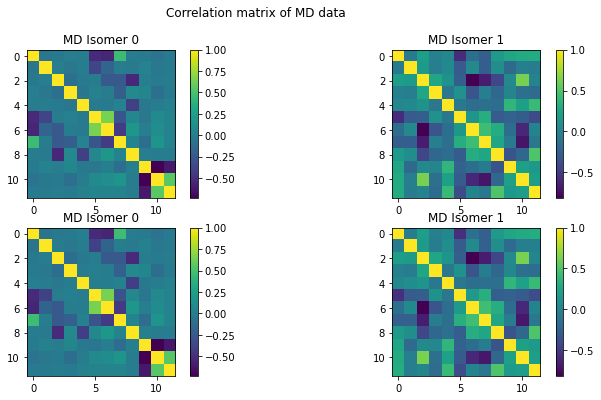

In [8]:
skip = 10
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

for i, ax in enumerate(axs[0]):
    im = ax.imshow(torch.corrcoef(md[i].transpose(0, 1)))
    # add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    ax.set_title("MD Isomer {:d}".format(i))

for i, ax in enumerate(axs[1]):
    im = ax.imshow(torch.corrcoef(md[i][::skip].transpose(0, 1)))
    # add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    ax.set_title("MD Isomer {:d}".format(i))

fig.suptitle("Correlation matrix of MD data")

# MD mutual information

Text(0.5, 0.98, 'Mutual information for MCMC')

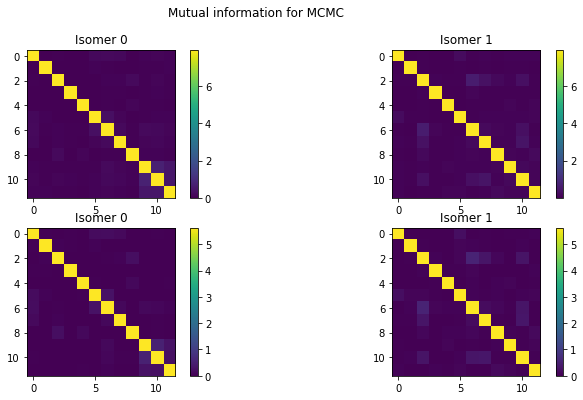

In [9]:
skip = 10
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

for i, ax in enumerate(axs[0]):
    mutual_info_matrix = []
    for j in range(12):
    #print(mutual_info_regression(mcmcs[0][::skip, 0].detach().numpy(), mcmcs[0][::skip, 0].detach().numpy()[:, i]))
        mutual_info_matrix.append(
            mutual_info_regression(md[i].reshape(-1, 12).detach().numpy(), md[i].reshape(-1, 12).detach().numpy()[:, j])
        )

    im = ax.imshow(mutual_info_matrix)
    # add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)

    ax.set_title("Isomer {:d}".format(i))

for i, ax in enumerate(axs[1]):
    mutual_info_matrix = []
    for j in range(12):
    #print(mutual_info_regression(mcmcs[0][::skip, 0].detach().numpy(), mcmcs[0][::skip, 0].detach().numpy()[:, i]))
        mutual_info_matrix.append(
            mutual_info_regression(md[i].reshape(-1, 12)[::skip].detach().numpy(), md[i].reshape(-1, 12)[::skip].detach().numpy()[:, j])
        )

    im = ax.imshow(mutual_info_matrix)
    # add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)

    ax.set_title("Isomer {:d}".format(i))

fig.suptitle("Mutual information for MCMC")